In [1]:
# ============================================================
# 1. 라이브러리 및 환경 설정
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format','{:.2f}'.format)

In [2]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

train = pd.read_csv("../../data/interim/train_missing_handled.csv")

cat_cols_for_bivariate = ['Sex','Embarked', 'Pclass','SibSp','Parch']
num_cols_for_bivariate = ['Age', 'Fare']

In [3]:
# ============================================================
# [추가] FamilySize / IsAlon 생성
# ============================================================

train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

# 분석 대상 컬럼에 추가
cat_cols_for_bivariate.append('IsAlone')

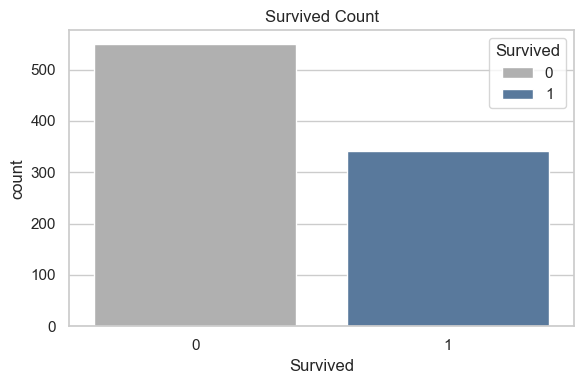

[Survived Count]
Survived
0    549
1    342
Name: count, dtype: int64

[Survived Ratio]
Survived
0   0.62
1   0.38
Name: proportion, dtype: float64


In [4]:
# ============================================================
# 3. 타겟 변수 분포 확인 및 저장
# ============================================================

plt.figure(figsize=(6,4))
sns.countplot(data=train, 
              x='Survived', 
              hue='Survived', 
              palette={0:'#b0b0b0', 1:'#4e79a7'}
             )
plt.title("Survived Count")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_survived_count.png", bbox_inches='tight')
plt.show()

print("[Survived Count]")
print(train['Survived'].value_counts())

print("\n[Survived Ratio]")
print(train['Survived'].value_counts(normalize=True))

[범주형 변수] Sex vs Survived

[교차표 - 개수]
Survived    0    1
Sex               
female     81  233
male      468  109

[교차표 - 비율]
Survived    0    1
Sex               
female   0.26 0.74
male     0.81 0.19

[범주별 평균 생존]
Sex
female   0.74
male     0.19
Name: Survived, dtype: float64


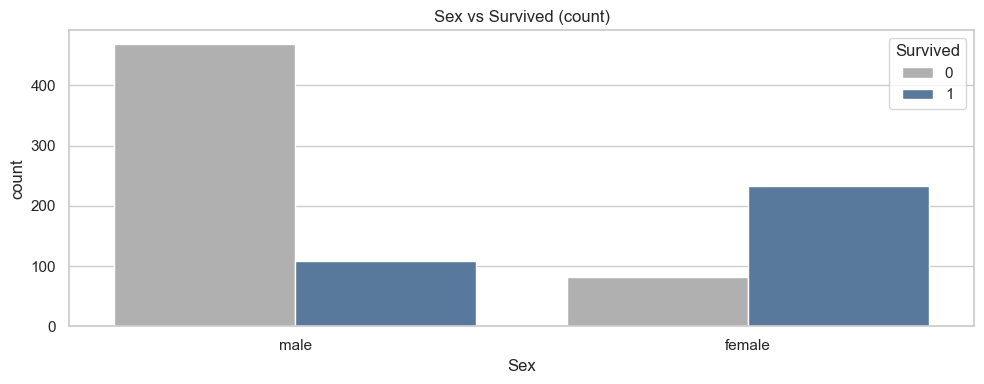

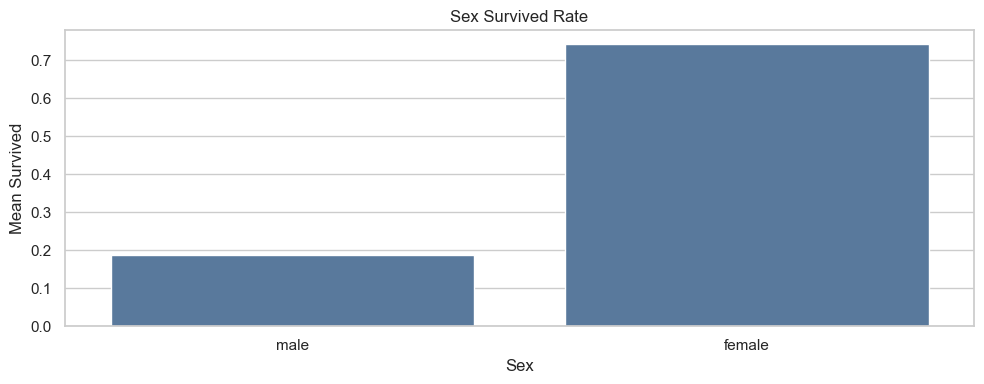

[범주형 변수] Embarked vs Survived

[교차표 - 개수]
Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  219

[교차표 - 비율]
Survived    0    1
Embarked          
C        0.45 0.55
Q        0.61 0.39
S        0.66 0.34

[범주별 평균 생존]
Embarked
C   0.55
Q   0.39
S   0.34
Name: Survived, dtype: float64


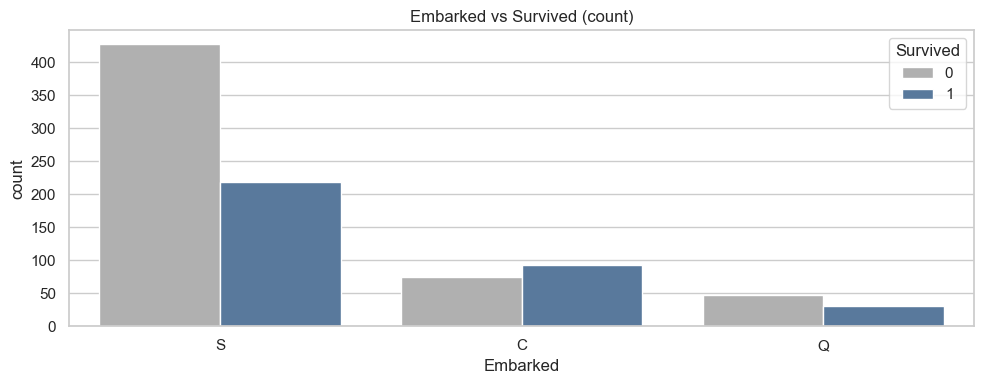

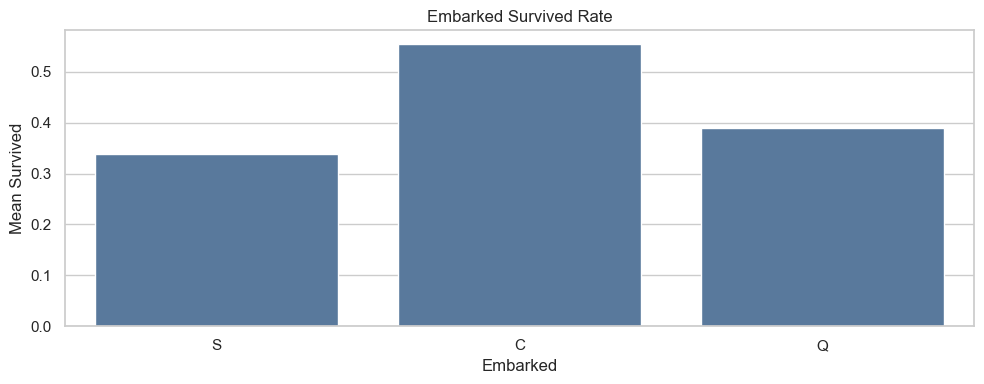

[범주형 변수] Pclass vs Survived

[교차표 - 개수]
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

[교차표 - 비율]
Survived    0    1
Pclass            
1        0.37 0.63
2        0.53 0.47
3        0.76 0.24

[범주별 평균 생존]
Pclass
1   0.63
2   0.47
3   0.24
Name: Survived, dtype: float64


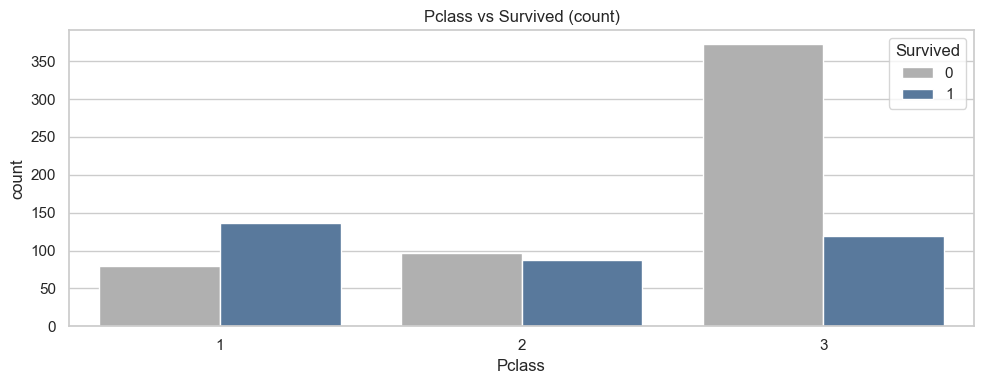

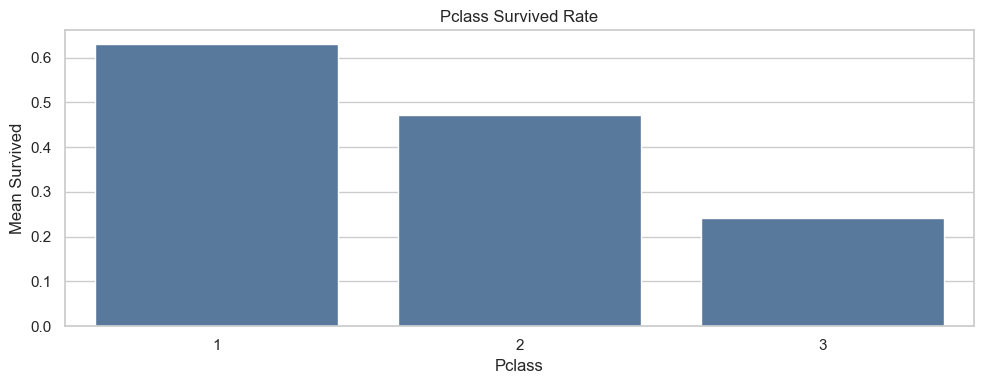

[범주형 변수] SibSp vs Survived

[교차표 - 개수]
Survived    0    1
SibSp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0

[교차표 - 비율]
Survived    0    1
SibSp             
0        0.65 0.35
1        0.46 0.54
2        0.54 0.46
3        0.75 0.25
4        0.83 0.17
5        1.00 0.00
8        1.00 0.00

[범주별 평균 생존]
SibSp
1   0.54
2   0.46
0   0.35
3   0.25
4   0.17
5   0.00
8   0.00
Name: Survived, dtype: float64


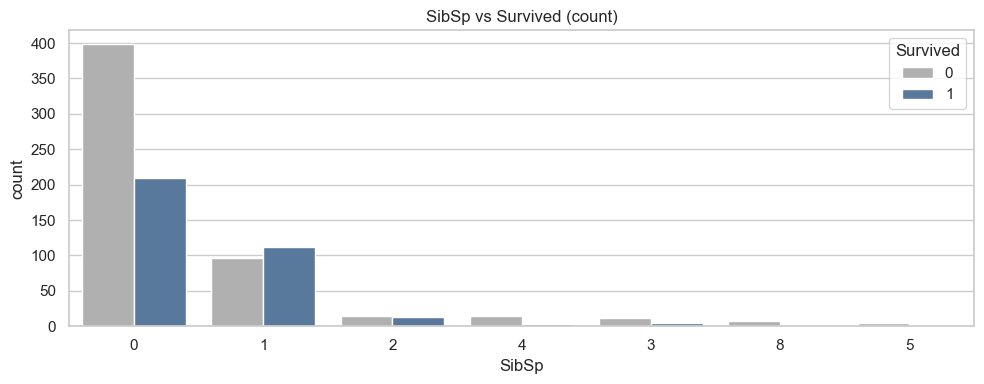

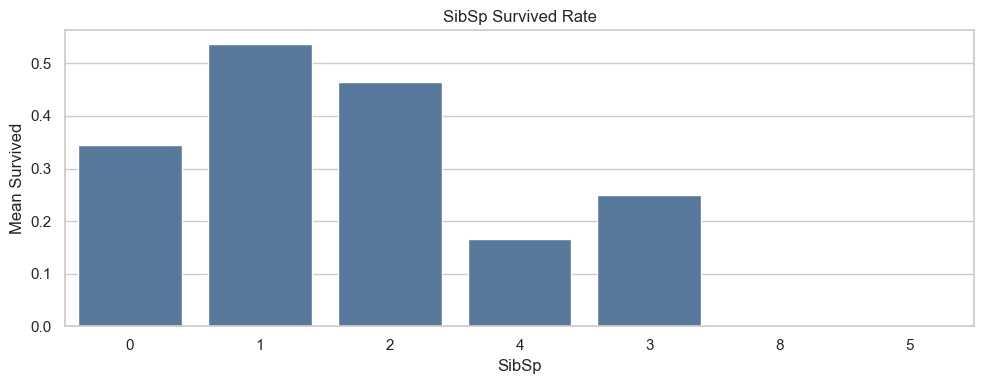

[범주형 변수] Parch vs Survived

[교차표 - 개수]
Survived    0    1
Parch             
0         445  233
1          53   65
2          40   40
3           2    3
4           4    0
5           4    1
6           1    0

[교차표 - 비율]
Survived    0    1
Parch             
0        0.66 0.34
1        0.45 0.55
2        0.50 0.50
3        0.40 0.60
4        1.00 0.00
5        0.80 0.20
6        1.00 0.00

[범주별 평균 생존]
Parch
3   0.60
1   0.55
2   0.50
0   0.34
5   0.20
4   0.00
6   0.00
Name: Survived, dtype: float64


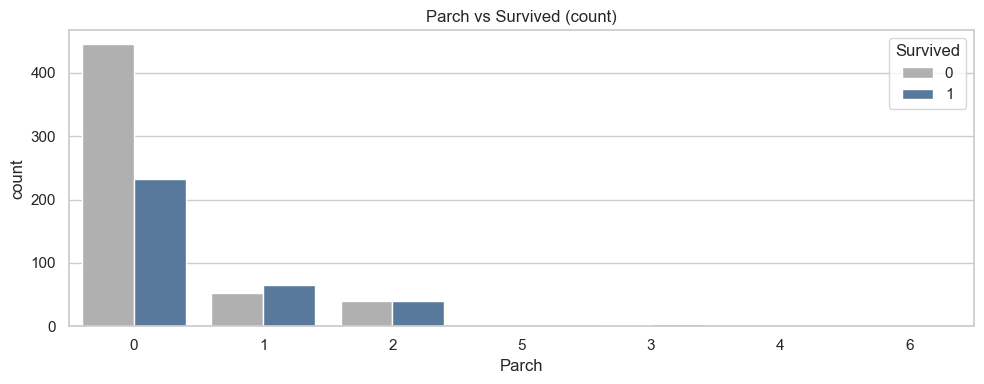

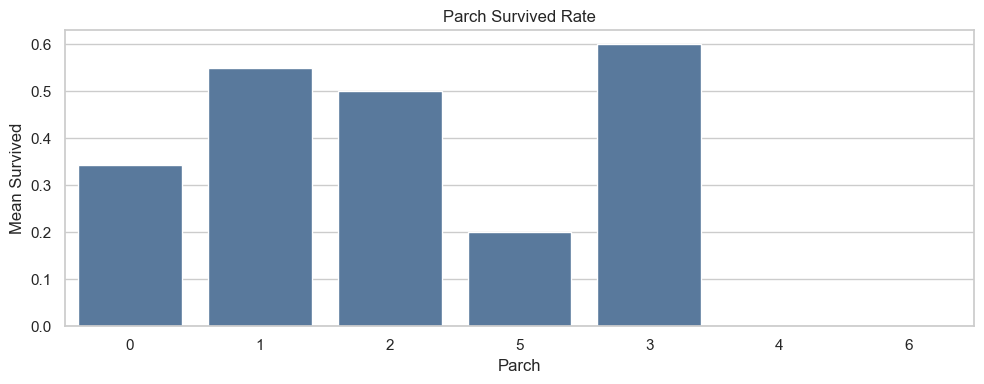

[범주형 변수] IsAlone vs Survived

[교차표 - 개수]
Survived    0    1
IsAlone           
0         175  179
1         374  163

[교차표 - 비율]
Survived    0    1
IsAlone           
0        0.49 0.51
1        0.70 0.30

[범주별 평균 생존]
IsAlone
0   0.51
1   0.30
Name: Survived, dtype: float64


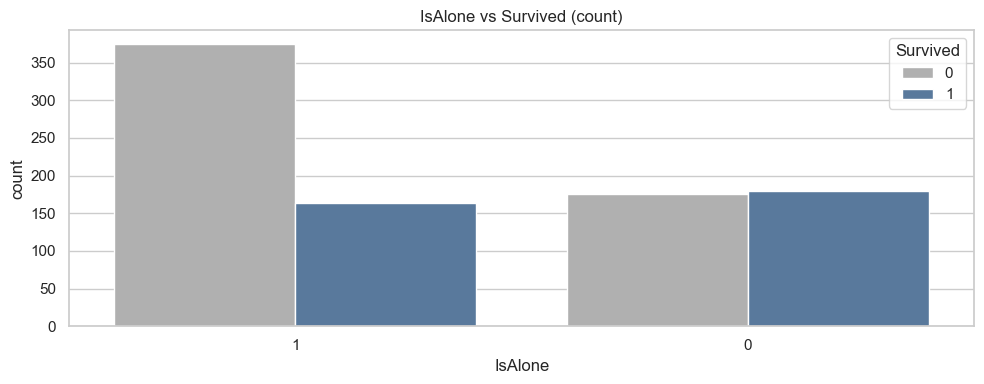

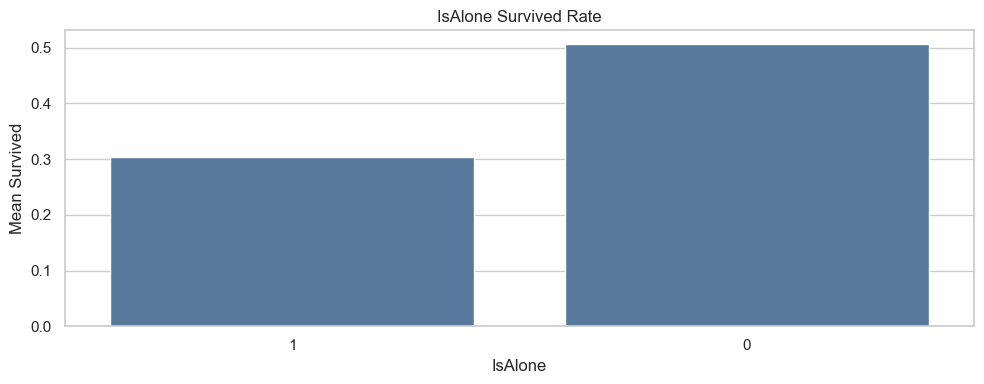

In [5]:
# ============================================================
# 4. 범주형 변수 vs 타겟 분석 및 저장
# ============================================================

for col in cat_cols_for_bivariate:
    print("=" * 60)
    print(f"[범주형 변수] {col} vs Survived")
    print("=" * 60)

    count_table = pd.crosstab(train[col], train['Survived'])
    print("\n[교차표 - 개수]")
    print(count_table)

    ratio_table = pd.crosstab(train[col], train['Survived'], normalize='index')
    print("\n[교차표 - 비율]")
    print(ratio_table)

    survived_rate = train.groupby(col)['Survived'].mean().sort_values(ascending=False)
    print("\n[범주별 평균 생존]")
    print(survived_rate)

    # ============================================================
    # 변수별 시각화 순서 설정
    # ============================================================
    if col == 'Pclass':
        order = [1, 2, 3]  # 의미 있는 순서
    else:
        order = train[col].value_counts(dropna=False).index  # 기존 방식

    # ============================================================
    # countplot
    # ============================================================
    plt.figure(figsize=(10,4))
    sns.countplot(
        data=train,
        x=col,
        hue='Survived',
        palette={0:'#b0b0b0', 1:'#4e79a7'},
        order=order
    )
    plt.title(f"{col} vs Survived (count)")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/bivariate_{col.lower()}_vs_survived_count.png", bbox_inches='tight')
    plt.show()

    # ============================================================
    # barplot (생존률)
    # ============================================================
    plt.figure(figsize=(10,4))
    sns.barplot(
        data=train,
        x=col,
        y='Survived',
        color='#4e79a7',
        order=order,
        errorbar=None
    )
    plt.title(f"{col} Survived Rate")
    plt.ylabel("Mean Survived")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/bivariate_{col.lower()}_survived_rate.png", bbox_inches='tight')
    plt.show()

[Embarked별 Pclass 개수]


Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,129,164,353



[Embarked별 Pclass 비율]


Pclass,1,2,3
Embarked,,,
C,0.51,0.10,0.39
Q,0.03,0.04,0.94
S,0.20,0.25,0.55


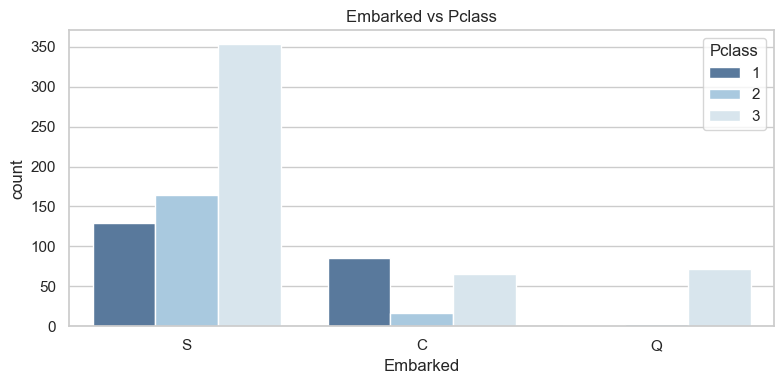

In [6]:
# ============================================================
# 4-1. Embarked와 Pclass 관계 확인
# - 탑승 항구별 객실 등급 분포를 확인한다.
# - Embarked의 생존률 차이가 Pclass 분포와 연관되어 있는지 참고한다.
# ============================================================

embarked_pclass_count = pd.crosstab(train['Embarked'], train['Pclass'])
print("[Embarked별 Pclass 개수]")
display(embarked_pclass_count)

embarked_pclass_ratio = pd.crosstab(
    train['Embarked'],
    train['Pclass'],
    normalize='index'
)

print("\n[Embarked별 Pclass 비율]")
display(embarked_pclass_ratio)

plt.figure(figsize=(8,4))
sns.countplot(
    data=train,
    x='Embarked',
    hue='Pclass',
    order=train['Embarked'].value_counts(dropna=False).index,
    palette = {
    1: '#4e79a7',  # 진한 파랑 (높은 등급)
    2: '#a0cbe8',  # 중간
    3: '#d4e6f1'   # 연한 색 (낮은 등급)
} 
)
plt.title("Embarked vs Pclass")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_embarked_vs_pclass_count.png", bbox_inches='tight')
plt.show()

Embarked별 생존률 차이는 있었지만,
탑승 항구에 따라 Pclass 분포가 다르게 나타난다.

특히 C 항구는 1등석 비율이 높았기 때문에
생존률이 높게 나타난 것으로 해석할 수 있다.

따라서 Embarked 자체의 영향이라기보다는
Pclass와의 연관성이 큰 변수라고 판단된다.

[숫자형 변수] Age vs Survived

[기술통계량]


,count,mean,median,std,min,max
Survived,,,,,,
0,549,30.03,28.00,12.50,1.00,74.00
1,342,28.48,28.00,13.81,0.42,80.00


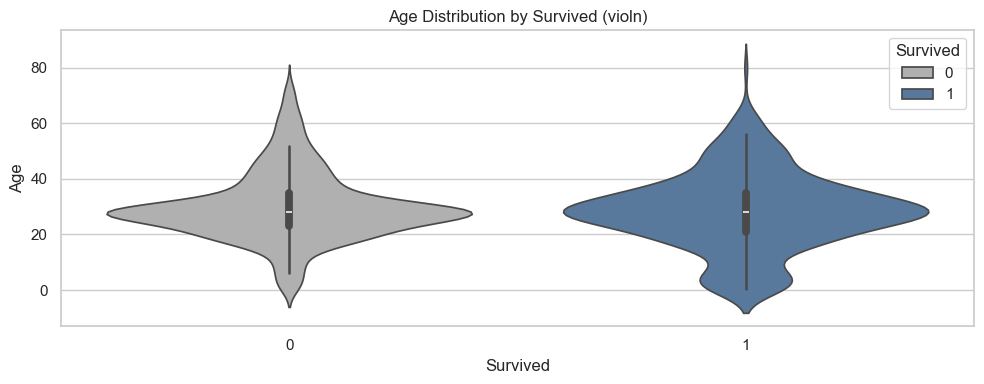

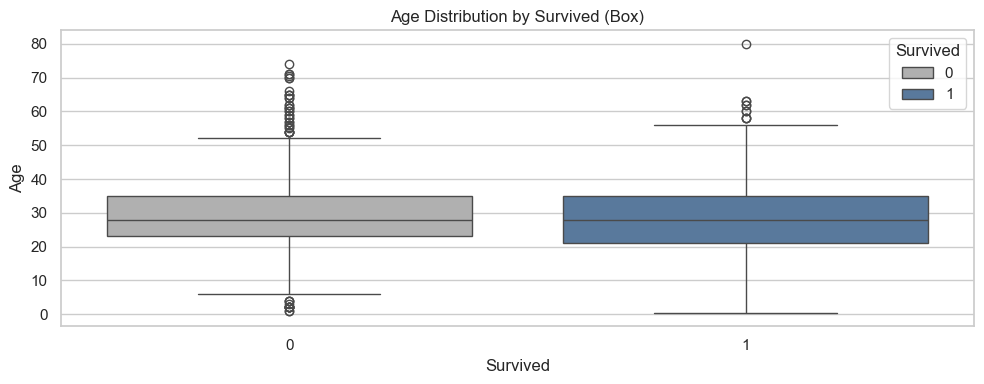

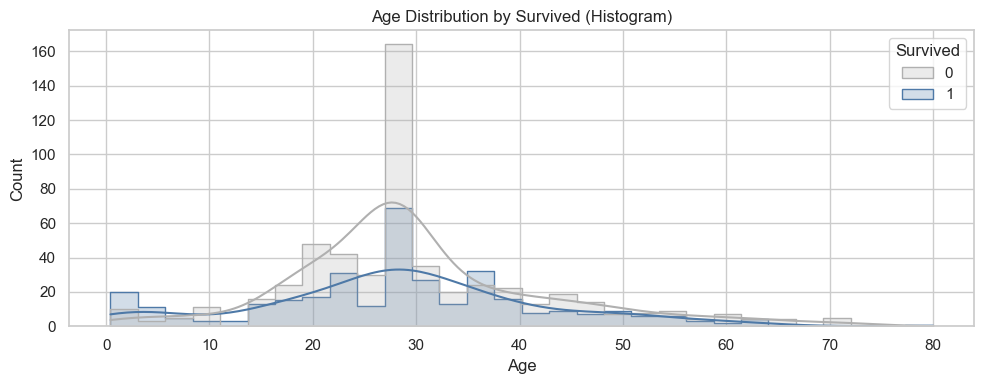

[숫자형 변수] Fare vs Survived

[기술통계량]


,count,mean,median,std,min,max
Survived,,,,,,
0,549,22.12,10.50,31.39,0.00,263.00
1,342,48.40,26.00,66.60,0.00,512.33


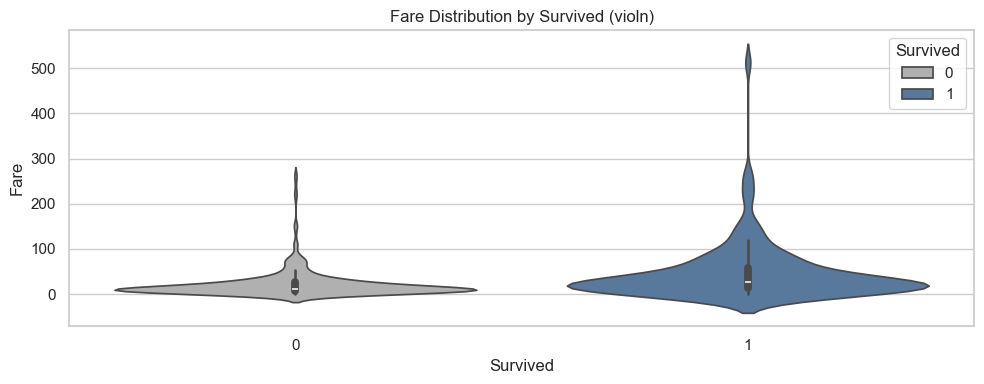

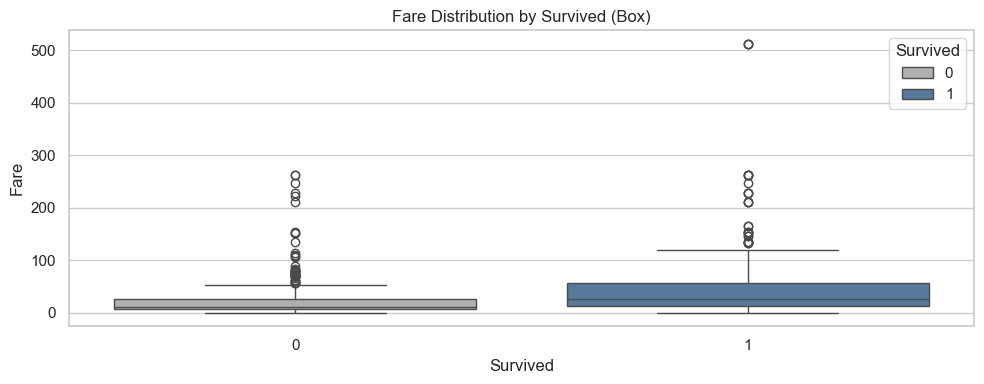

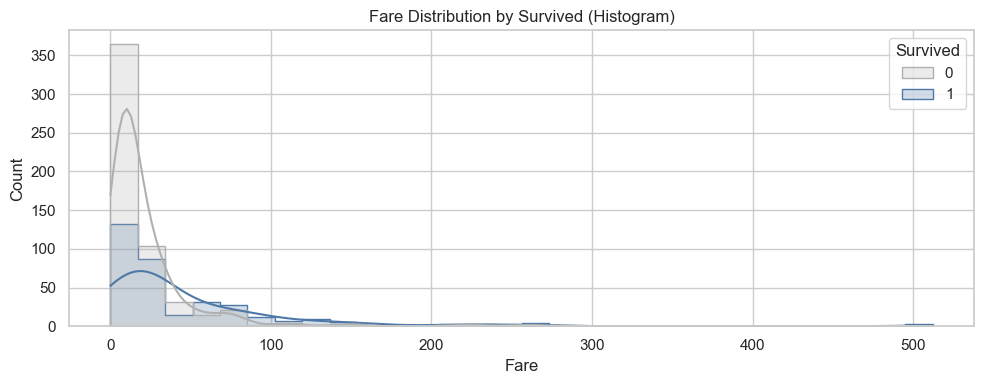

In [7]:
# ============================================================
# 5. 숫자형 변수 vs 타겟 분석 및 저장
# ============================================================

for col in num_cols_for_bivariate:
    print("=" * 60)
    print(f"[숫자형 변수] {col} vs Survived")
    print("=" * 60)

    summary_table = train.groupby('Survived')[col].agg(['count','mean','median','std','min','max'])
    print("\n[기술통계량]")
    display(summary_table)

    plt.figure(figsize=(10,4))
    sns.violinplot(
        data=train,
        x='Survived',
        y=col,
        inner='box',
        hue='Survived',
        palette={0:'#b0b0b0', 1:'#4e79a7'}
    )
    plt.title(f"{col} Distribution by Survived (violn)")
    plt.tight_layout()
    plt.savefig(f"../../output/figures/bivariate_{col.lower()}_violin_by_survived.png", bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,4))
    sns.boxplot(
        data=train,
        x='Survived',
        y=col,
        hue='Survived',
        palette={0:'#b0b0b0', 1:'#4e79a7'}
    )
    plt.title(f"{col} Distribution by Survived (Box)")
    plt.tight_layout()
    plt.savefig("../../output/figures/bivariate_{col.lower()}_box_by_survived.png", bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(10,4))
    sns.histplot(
        data=train,
        x=col,
        hue='Survived',
        kde=True,
        bins=30,
        element='step',
        palette={0:'#b0b0b0', 1:'#4e79a7'}
    )
    plt.title(f"{col} Distribution by Survived (Histogram)")
    plt.tight_layout()
    plt.savefig("../../output/figures/bivariate_{col.lower()}_hist_by_survived.png", bbox_inches='tight')
    plt.show()

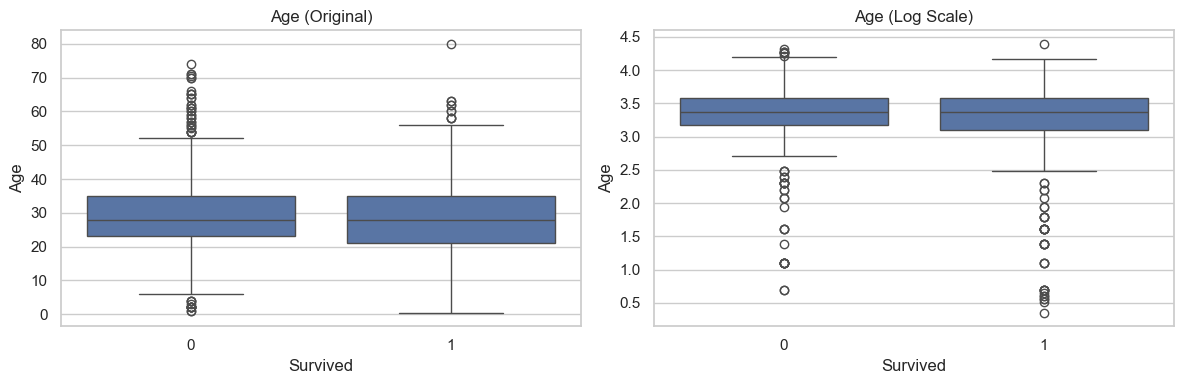

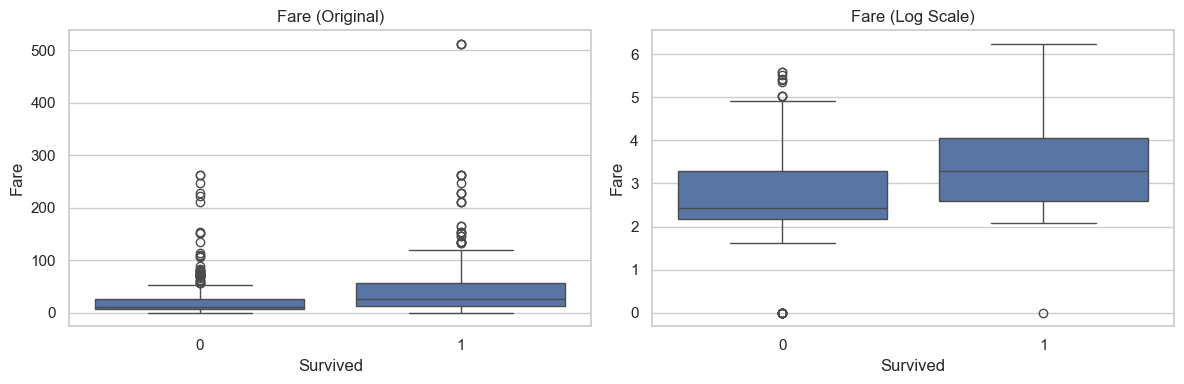

In [8]:
# ============================================================
# 6. 로그 변환 비교 및 저장
# ============================================================

for col in num_cols_for_bivariate:
    fig, axes = plt.subplots(1, 2, figsize=(12,4))

    sns.boxplot(
        data=train,
        x="Survived",
        y=col,
        ax=axes[0]
    )
    axes[0].set_title(f"{col} (Original)")

    sns.boxplot(
        x=train['Survived'], 
        y=np.log1p(train[col]),
        ax=axes[1]
    )
    axes[1].set_title(f"{col} (Log Scale)")

    plt.tight_layout()
    plt.savefig("../../output/figures/bivariate_{col.lower()}_original_vs_lob_boxplot.png", bbox_inches='tight')
    plt.show()

In [9]:
# ============================================================
# 7. Age 구간 기준 탐색 : 여러 기준 비교
# ============================================================

# Age는 연속형 변수이므로 먼저 여러 구간화 기준을 비교한다.
# 목적: 어떤 구간에서 생존률 차이가 뚜렷한지 확인한 뒤 AgeBand 기준을 정한다.

age_cut_10 = pd.cut(train['Age'], bins=10)

age_cut_domain = pd.cut(
    train['Age'],
    bins=[0,10,20,40,60,80],
    labels=['Child','Teen','YoungAdult','Adult','Senior'],
    include_lowest=True
)

age_qcut_5 = pd.qcut(
    train['Age'],
    q=5,
    duplicates='drop'
)

print("=" * 60)
print("[Age 구간화 기준 비교]")
print("=" * 60)

print("\n[1] Age 균등 10구간: 생존률 + 표본 수")
age_cut_10_summary = train.groupby(age_cut_10, observed=False)['Survived'].agg(survival_rate='mean',count='count')
display(age_cut_10_summary)

print("\n[2] Age 도메인/해석 기반 구간: 생존률 + 표본 수")
age_cut_domain_summary = train.groupby(age_cut_domain, observed=False)['Survived'].agg(survival_rate='mean',count='count')
display(age_cut_domain_summary)

print("\n[3] Age 분위수 5구간(qcut): 생존률 + 표본 수")
age_qcut_5_summary = train.groupby(age_qcut_5, observed=False)['Survived'].agg(survival_rate='mean', count='count')
display(age_qcut_5_summary)


[Age 구간화 기준 비교]

[1] Age 균등 10구간: 생존률 + 표본 수


,survival_rate,count
Age,,
"(0.34, 8.378]",0.67,54
"(8.378, 16.336]",0.41,46
"(16.336, 24.294]",0.36,177
"(24.294, 32.252]",0.32,337
"(32.252, 40.21]",0.48,127
"(40.21, 48.168]",0.34,70
"(48.168, 56.126]",0.47,45
"(56.126, 64.084]",0.38,24
"(64.084, 72.042]",0.00,9



[2] Age 도메인/해석 기반 구간: 생존률 + 표본 수


,survival_rate,count
Age,,
Child,0.59,64
Teen,0.38,115
YoungAdult,0.36,562
Adult,0.39,128
Senior,0.23,22



[3] Age 분위수 5구간(qcut): 생존률 + 표본 수


,survival_rate,count
Age,,
"(0.419, 20.0]",0.46,179
"(20.0, 28.0]",0.31,351
"(28.0, 29.0]",0.36,22
"(29.0, 38.0]",0.48,162
"(38.0, 80.0]",0.37,177


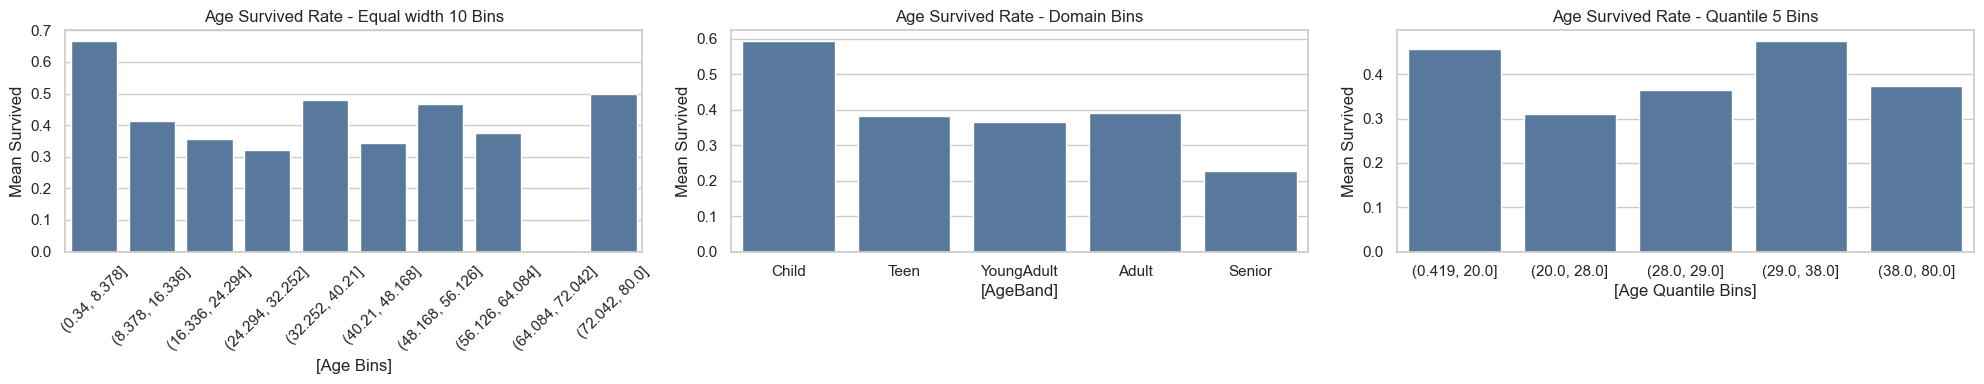

In [10]:
# ============================================================
# 8. Age 구간화 기준 시각화 비교
# ============================================================

fig, axes = plt.subplots(1,3,figsize=(20,4))

sns.barplot(
    x=age_cut_10,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Age Survived Rate - Equal width 10 Bins")
axes[0].set_xlabel("[Age Bins]")
axes[0].set_ylabel("Mean Survived")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    x=age_cut_domain,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Age Survived Rate - Domain Bins")
axes[1].set_xlabel("[AgeBand]")
axes[1].set_ylabel("Mean Survived")

sns.barplot(
    x=age_qcut_5,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None,
    ax=axes[2]
)
axes[2].set_title("Age Survived Rate - Quantile 5 Bins")
axes[2].set_xlabel("[Age Quantile Bins]")
axes[2].set_ylabel("Mean Survived")

plt.tight_layout()
plt.savefig("../../output/figures/bivariate_ageband_comparison.png", bbox_inches='tight')
plt.show()

In [11]:
# bar 없는 부분 체크용 
print(age_cut_10.value_counts(dropna=False).sort_index())

Age
(0.34, 8.378]        54
(8.378, 16.336]      46
(16.336, 24.294]    177
(24.294, 32.252]    337
(32.252, 40.21]     127
(40.21, 48.168]      70
(48.168, 56.126]     45
(56.126, 64.084]     24
(64.084, 72.042]      9
(72.042, 80.0]        2
Name: count, dtype: int64


###  Age 구간화 기준 비교 결과

####  Equal Width 10 Bins

- 가장 어린 구간은 생존률이 약 **0.66**으로 높음  
- 20~30대 초반 구간은 생존률이 **0.3대 초반**으로 낮음  
- 중간 구간에서 생존률이 불안정하게 변동  
- **64~72 구간은 생존률 0**으로 막대가 보이지 않음  
- **72~80 구간은 생존률 0.5지만 표본 수가 2명으로 신뢰도 낮음**

결론:  
구간이 세분화되어 패턴은 보이지만, **표본 수 부족으로 노이즈가 많음**

---

####  Domain Bins

- Child: 생존률 **약 0.59 (높음)**  
- Teen ~ Adult: 생존률 **0.36 ~ 0.39 수준으로 유사**  
- Senior: 생존률 **약 0.23 (가장 낮음)**  

결론:  
- **어린 나이일수록 생존률이 높고, 고령일수록 낮음**  
- 구간 의미가 직관적이며 **해석이 가장 용이함**

---

####  Quantile 5 Bins (qcut)

- 20~28세 구간은 생존률이 가장 낮음  
- 29~38세 구간은 상대적으로 높은 생존률  
- (28~29) 구간처럼 **비정상적으로 좁은 구간 존재**

결론:  
- 데이터 분포 기반이라 균형은 좋지만  
- **구간 의미가 직관적이지 않아 해석이 어려움**

---

###  최종 결론

- Equal width: 노이즈 많음 
- Quantile: 해석 어려움  
- Domain bins: 해석력 + 안정성 모두 우수 

 따라서 **AgeBand는 Domain 기반 구간을 최종 선택**

[최종 AgeBand 후보]


,survival_rate,count
Age,,
Child,0.59,64
Teen,0.38,115
YoungAdult,0.36,562
Adult,0.39,128
Senior,0.23,22


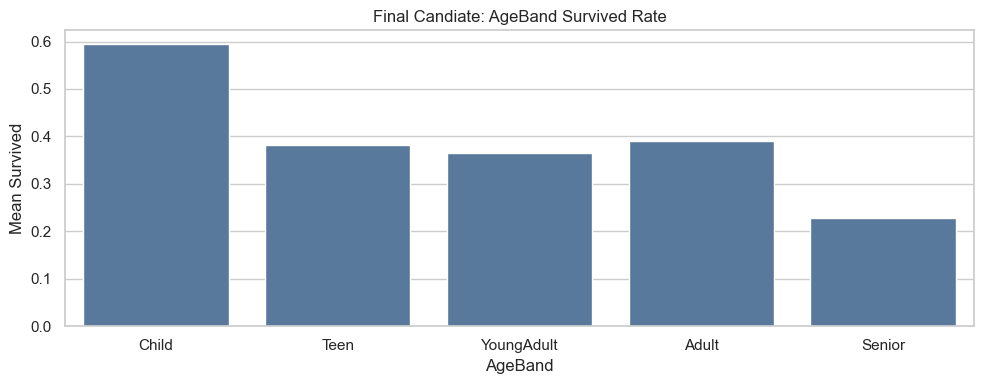

In [12]:
# ============================================================
# 9. AgeBand 최종 후보 선택 및 저장
# ============================================================

# 위 비교 결과를 바탕으로 최종 후보를 설정한다.
# 선택 기준:
# 1. 구간별 생존률 차이가 해석 가능해야 한다.
# 2. 각 국간의 표본 수가 너무 작지 않아야 한다.
# 3. 모델링 단계에서 설명 가능한 변수여야 한다.

age_band = age_cut_domain

print("=" * 60)
print("[최종 AgeBand 후보]")
print("=" * 60)

age_band_summary = train.groupby(age_band, observed=False)['Survived'].agg(survival_rate='mean', count='count')
display(age_band_summary)

plt.figure(figsize=(10,4))
sns.barplot(
    x=age_band,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None
)
plt.title("Final Candiate: AgeBand Survived Rate")
plt.xlabel("AgeBand")
plt.ylabel("Mean Survived")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_ageband_survived_rate.png", bbox_inches='tight')
plt.show()

[Fare 분포 확인]

[Fare 기술 통계량]


count   891.00
mean     32.20
std      49.69
min       0.00
25%       7.91
50%      14.45
75%      31.00
max     512.33
Name: Fare, dtype: float64

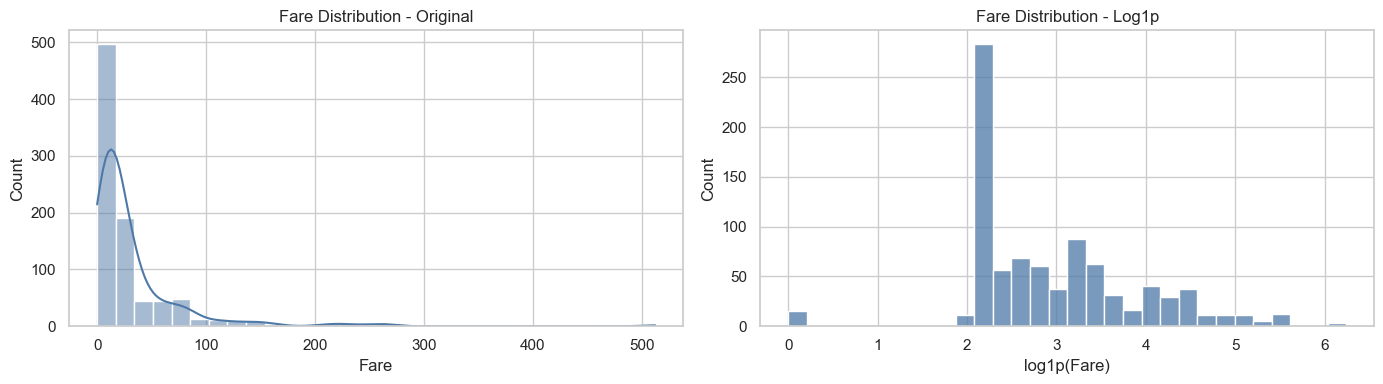

In [13]:
# ============================================================
# 10. Fare 구간 기준 탐색 : 분포 확인
# ============================================================

print("=" * 60)
print("[Fare 분포 확인]")
print("=" * 60)

print("\n[Fare 기술 통계량]")
display(train['Fare'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(
    train['Fare'],
    bins=30,
    kde=True,
    color='#4e79a7',
    ax=axes[0]
)
axes[0].set_title("Fare Distribution - Original")
axes[0].set_xlabel("Fare")

sns.histplot(
    np.log1p(train['Fare']),
    bins=30,
    color='#4e79a7',
    ax=axes[1]
)
axes[1].set_title("Fare Distribution - Log1p")
axes[1].set_xlabel("log1p(Fare)")

plt.tight_layout()
plt.savefig("../../output/figures/bivariate_fare_distribution_original_vs_log.png", bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# 11. Fare 구간화 기준 비교
# ============================================================

# Fare는 오른쪽으로 긴 꼬리가 있는 변수이므로,
# 균등 구간보다 분위수 기반 qcut이 표본 수 균형에 유리한지 비교한다.

fare_cut_4 = pd.cut(train['Fare'], bins=4)

fare_qcut_4 = pd.qcut(
    train['Fare'],
    q=4,
    labels=['Low','MidLow','MidHigh','High'],
    duplicates='drop'
)

print("=" * 60)
print("[Fare 구간화 기준 비교]")
print("=" * 60)

print("\n[1] Fare 균등 4구간: 생존률 + 표본 수")
fare_cut_4_summary = train.groupby(fare_cut_4, observed=False)['Survived'].agg(survived_rate='mean', count='count')
display(fare_cut_4_summary)

print("\n[2] Fare 분위수 4구간(qcut): 생존률 + 표본 수")
fare_qcut_4_summary = train.groupby(fare_qcut_4, observed=False)['Survived'].agg(survived_rare='mean', count='count')
display(fare_qcut_4_summary)

[Fare 구간화 기준 비교]

[1] Fare 균등 4구간: 생존률 + 표본 수


,survived_rate,count
Fare,,
"(-0.512, 128.082]",0.37,853
"(128.082, 256.165]",0.72,29
"(256.165, 384.247]",0.67,6
"(384.247, 512.329]",1.00,3



[2] Fare 분위수 4구간(qcut): 생존률 + 표본 수


,survived_rare,count
Fare,,
Low,0.20,223
MidLow,0.30,224
MidHigh,0.45,222
High,0.58,222


Fare는 생존과 강한 양의 관계를 보이며,
특히 분위 기반 분석(qcut)에서 요금이 증가할수록 생존률이 점진적으로 증가하는 패턴이 명확하게 나타난다

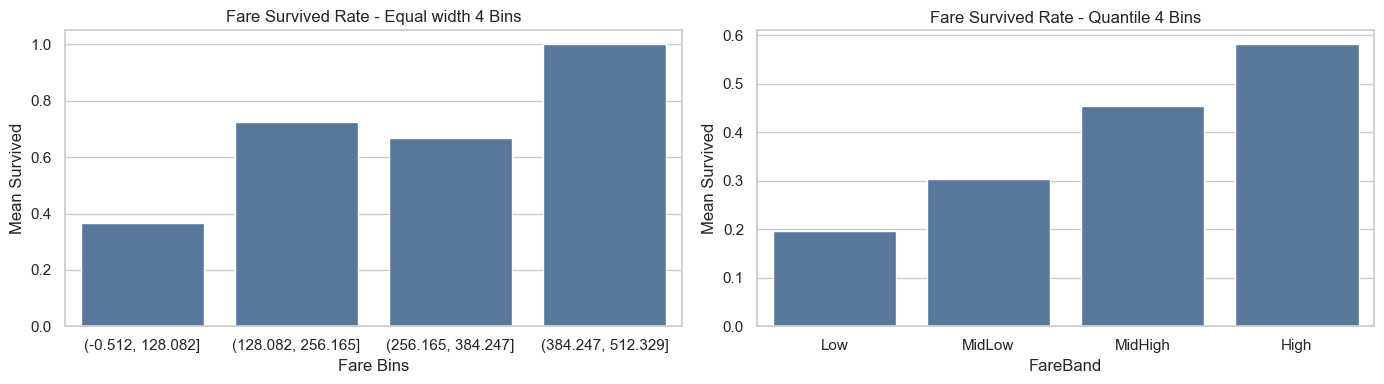

In [15]:
# ============================================================
# 12. Fare 구간화 기준 시각화 비교
# ============================================================

fig, axes = plt.subplots(1,2,figsize=(14,4))

sns.barplot(
    x=fare_cut_4,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None,
    ax=axes[0]
)
axes[0].set_title("Fare Survived Rate - Equal width 4 Bins")
axes[0].set_xlabel("Fare Bins")
axes[0].set_ylabel("Mean Survived")

sns.barplot(
    x=fare_qcut_4,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None,
    ax=axes[1]
)
axes[1].set_title("Fare Survived Rate - Quantile 4 Bins")
axes[1].set_xlabel("FareBand")
axes[1].set_ylabel("Mean Survived")

plt.tight_layout()
plt.savefig("../../output/figures/bivariate_fareband_comparison.png", bbox_inches='tight')
plt.show()

[최종 FareBand 후보]


,survived_rate,count
Fare,,
Low,0.20,223
MidLow,0.30,224
MidHigh,0.45,222
High,0.58,222


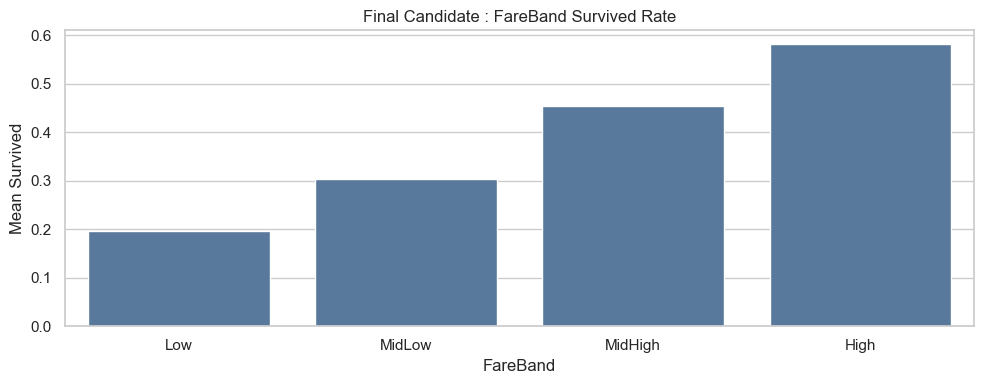

In [16]:
# ============================================================
# 13. FareBand 최종 후보 선택 및 저장
# ============================================================

# 위 비교 결과를 바탕으로 최종 후보를 qcut 기준으로 설정한다.
# 선택 기준:
# 1. Fare는 분포가 심하게 치우쳐 있으므로 균등 구간보다 qcut이 표본수 균형에 유리하다.
# 2. 구간별 생존률 차이가 뚜렷하게 나타나는지 확인한다.

fare_band = fare_qcut_4

print("=" * 60)
print("[최종 FareBand 후보]")
print("=" * 60)

fare_band_summary = train.groupby(fare_band, observed=False)['Survived'].agg(survived_rate='mean', count='count')
display(fare_band_summary)

plt.figure(figsize=(10,4))
sns.barplot(
    x=fare_band,
    y=train['Survived'],
    color='#4e79a7',
    errorbar=None
)
plt.title("Final Candidate : FareBand Survived Rate")
plt.xlabel("FareBand")
plt.ylabel("Mean Survived")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_fareband_survived_rate.png", bbox_inches='tight')
plt.show()

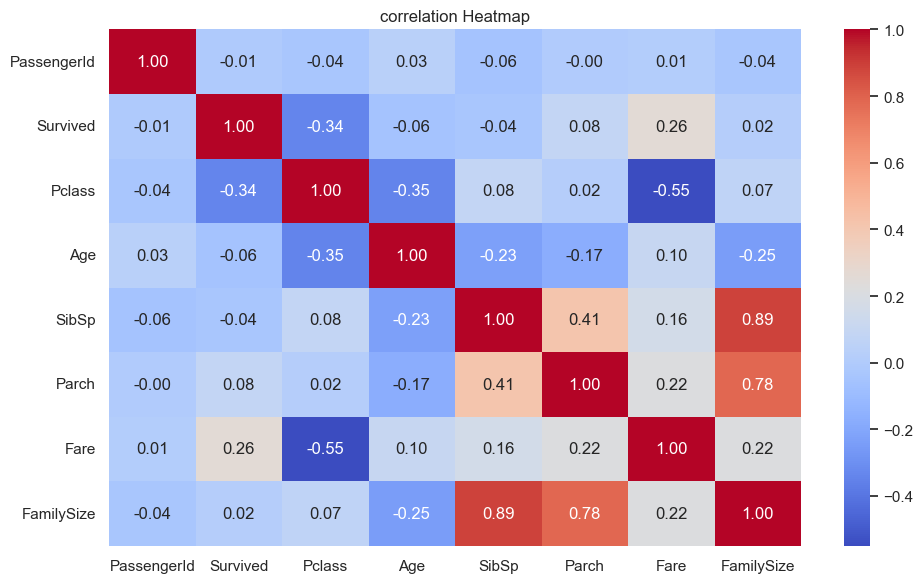

In [17]:
# ============================================================
# 14. 상관관계 히트맵 저장
# ============================================================

plt.figure(figsize=(10,6))
sns.heatmap(
    train.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("correlation Heatmap")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_correlation_heatmap.png", bbox_inches='tight')
plt.show()

Pclass vs Survived → -0.34
등급 낮을수록 많이 죽음

Fare vs Survived → 0.26
돈 많을수록 많이 산다

Age vs Survived → -0.06
나이는 영향 거의 없음

SibSp vs Survived → -0.04
거의 0
영향 거의 없음

Parch vs Survived → 0.08
약간 있지만 거의 의미 없음


================

Pclass vs Fare → -0.55
등급 낮을수록 요금 낮음
Pclass랑 Fare는 거의 같은 정보다 (강한 관계)

SibSp vs Parch → 0.41
형제 많으면 부모도 같이 있는 경우 많음
가족 변수끼리 연결됨

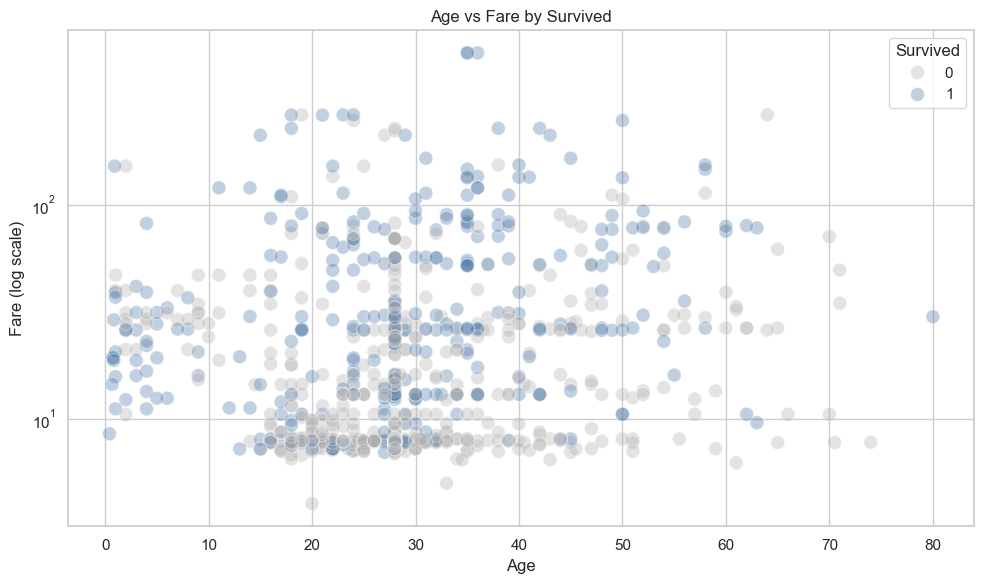

In [18]:
# ============================================================
# 15-1. 숫자형 변수 scatter 
# ============================================================

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=train,
    x='Age',
    y='Fare',
    hue='Survived', 
    palette={0:'#b0b0b0', 1:'#4e79a7'},
    alpha=0.35,
    s=100
)
plt.yscale('log')

plt.title("Age vs Fare by Survived")
plt.ylabel("Fare (log scale)")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_age_vs_fare_scatter.png", bbox_inches='tight')
plt.show()

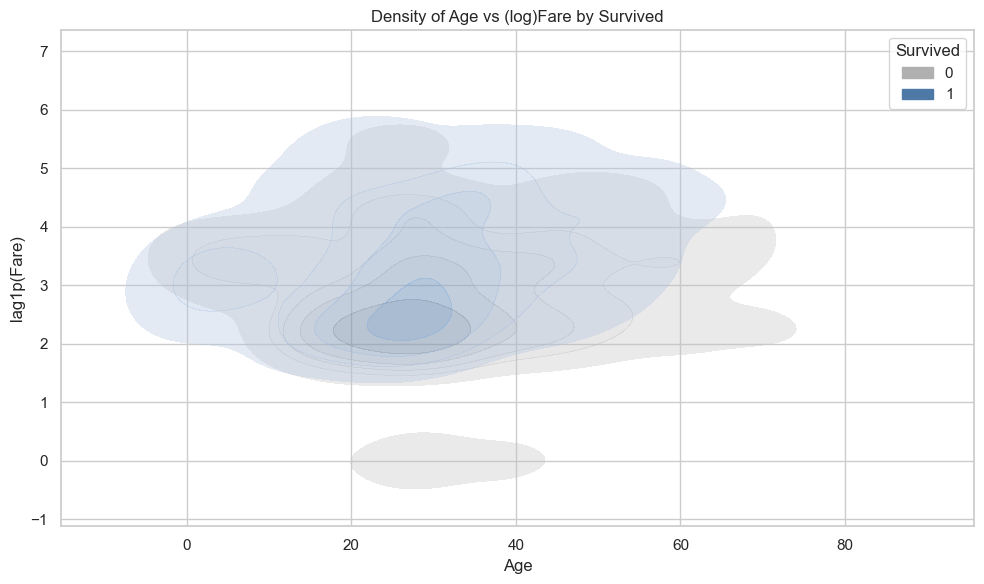

In [19]:
# ============================================================
# 15-2. 숫자형 변수 KDE Plot (밀도 확인)
# ============================================================

# log1p(Fare) 값을 새 컬럼으로 만들어 시각화한다.
train_plot = train.copy()
train_plot['Fare_log'] = np.log1p(train_plot['Fare'])

#Age, Fare_log, Survived에 결측이 있는 행은 그래프에서 제외한다.
train_plot = train_plot.dropna(subset=['Age','Fare_log','Survived'])
    
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=train_plot,
    x='Age',
    y='Fare_log',
    hue='Survived',
    palette={0:'#b0b0b0', 1:'#4e79a7'},
    fill=True,
    alpha=0.35,
    levels=6,
    thresh=0.05
)

plt.title("Density of Age vs (log)Fare by Survived")
plt.ylabel("lag1p(Fare)")
plt.tight_layout()
plt.savefig("../../output/figures/bivariate_age_vs_fare_kde.png", bbox_inches='tight')
plt.show()

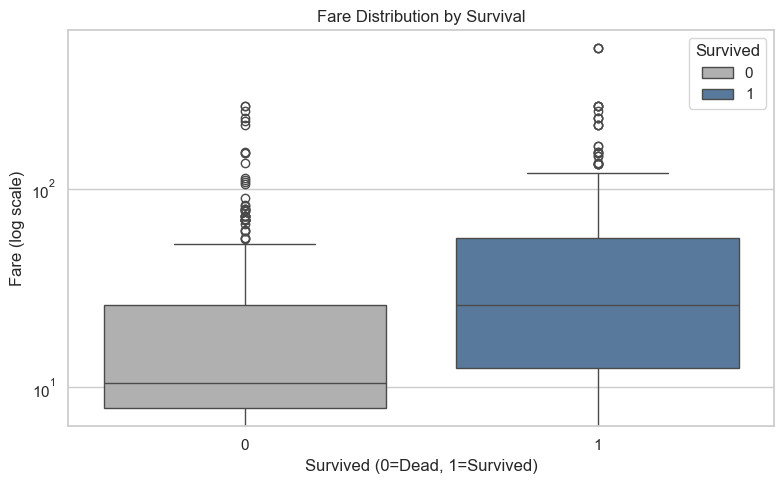

In [20]:
# ============================================================
# 15-3. Fare vs Survived (Boxplot)
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x='Survived',
    y='Fare',
    hue='Survived',
    palette={0:'#b0b0b0', 1:'#4e79a7'}
)

plt.yscale('log')

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0=Dead, 1=Survived)")
plt.ylabel("Fare (log scale)")

plt.tight_layout()
plt.savefig("../../output/figures/bivariate_fare_boxplot.png", bbox_inches='tight')
plt.show()

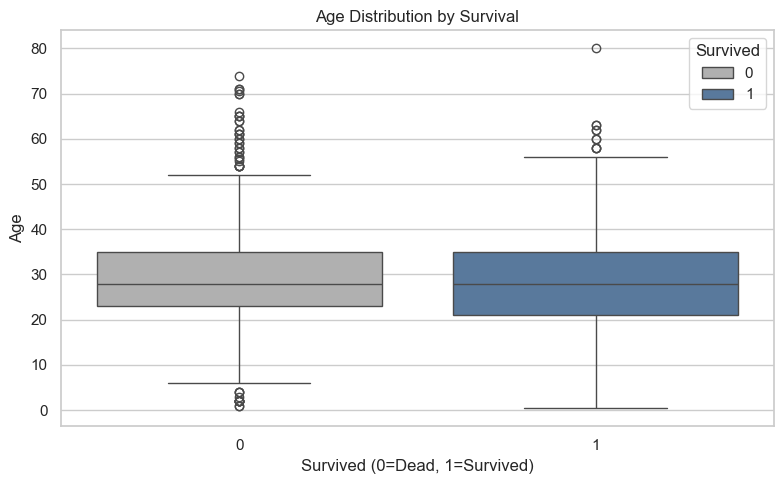

In [21]:
# ============================================================
# 15-4. Age vs Survived (Boxplot)
# ============================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x='Survived',
    y='Age',
    hue='Survived',
    palette={0:'#b0b0b0', 1:'#4e79a7'}
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0=Dead, 1=Survived)")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig("../../output/figures/bivariate_age_boxplot.png", bbox_inches='tight')
plt.show()